# Explicabilidad con LIME y Comparación de Frameworks

<div style="background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); color:#f8fafc; padding:28px 32px; border-radius:18px; margin-bottom:16px; border-left:6px solid #c4b5fd; box-shadow:0 20px 45px rgba(0,0,0,0.35);">

  <p style="margin:0; font-size:1.05rem; line-height:1.65; color:#94a3b8;">
    Este notebook explica predicciones individuales del modelo MLP con <b style="color:#f8fafc;">LIME</b> y consolida la <b style="color:#f8fafc;">comparación final</b> entre scikit-learn y PySpark.
  </p>
</div>

<p style="margin-bottom:18px;">
  <span style="background-color:#0f172a; color:#c4b5fd; border:1px solid #c4b5fd; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem;">Interpretabilidad: LIME</span>
  <span style="background-color:#0f172a; color:#90be6d; border:1px solid #90be6d; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">Comparación de frameworks</span>
  <span style="background-color:#0f172a; color:#f28482; border:1px solid #f28482; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">Reflexión crítica</span>
</p>

<div style="display:flex; flex-wrap:wrap; gap:10px; margin-bottom:14px;">
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); border-left:4px solid #c4b5fd; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#c4b5fd; font-size:0.95rem;">Contenido</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      1. <b style="color:#e2e8f0;">Carga del modelo</b> entrenado y datos de prueba<br>
      2. <b style="color:#e2e8f0;">Explicaciones LIME</b> — falso positivo y falso negativo<br>
      3. <b style="color:#e2e8f0;">Resumen de contribuciones</b> — features positivas vs negativas<br>
      4. <b style="color:#e2e8f0;">Comparación de frameworks</b> — métricas, ROC, tiempos<br>
      5. <b style="color:#e2e8f0;">Reflexión crítica</b> sobre resultados y decisiones
    </p>
  </div>
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); border-left:4px solid #90be6d; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#90be6d; font-size:0.95rem;">Requisitos</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      Modelo guardado en <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">models/</code><br>
      Datos de prueba del Notebook 2<br>
      Librerías: scikit-learn, lime, pandas, matplotlib, seaborn
    </p>
  </div>
</div>

<div style="background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #c4b5fd; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0 0 12px 0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    Notebook roadmap
  </h2>
  <div style="display:flex; flex-wrap:wrap; gap:8px;">
    <span style="background-color:rgba(196,181,253,0.1); border:1px solid rgba(196,181,253,0.25); color:#e0e7ff; padding:6px 14px; border-radius:8px; font-size:0.88rem; line-height:1.5;">Reload the sampled dataset created for the local workflow</span>
    <span style="background-color:rgba(196,181,253,0.1); border:1px solid rgba(196,181,253,0.25); color:#e0e7ff; padding:6px 14px; border-radius:8px; font-size:0.88rem; line-height:1.5;">Fit a local MLP pipeline compatible with LIME</span>
    <span style="background-color:rgba(196,181,253,0.1); border:1px solid rgba(196,181,253,0.25); color:#e0e7ff; padding:6px 14px; border-radius:8px; font-size:0.88rem; line-height:1.5;">Explain an individual click prediction</span>
    <span style="background-color:rgba(196,181,253,0.1); border:1px solid rgba(196,181,253,0.25); color:#e0e7ff; padding:6px 14px; border-radius:8px; font-size:0.88rem; line-height:1.5;">Summarize what LIME adds and when each framework is most useful</span>
  </div>
</div>

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("No se encontró la raíz del proyecto con el directorio src.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from ctr_mlp.config import load_project_settings, apply_dark_style, COLORS, AXES_BG
from ctr_mlp.data_io import split_features_target
from ctr_mlp.evaluation import (
    compute_binary_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_comparative_roc,
    plot_comparative_times,
    build_comparison_table,
)
from ctr_mlp.explainability import (
    build_lime_explainer_from_pipeline,
    explain_pipeline_prediction,
    explanation_to_frame,
    find_misclassified_instances,
)
from ctr_mlp.feature_engineering import add_time_features_pandas
from ctr_mlp.sklearn_workflow import split_train_test
from ctr_mlp.utils import format_seconds

# Aplicar estilo oscuro profesional
apply_dark_style()

settings = load_project_settings()
paths = settings["paths"]
general = settings["general"]
feature_cfg = settings["features"]

FIGURES_DIR = paths["figures_dir"]
MODELS_DIR = paths["models_dir"]
TARGET_COL = general["target_col"]

## 1. Reload the sample

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;"> &nbsp;This notebook uses the same sampled dataset as the scikit-learn workflow. If the sample does not exist yet, it is regenerated from the compressed source file.
  </h2>
</div>


In [2]:
# Cargar modelo guardado
model_path = Path(MODELS_DIR) / "sklearn_best_mlp.joblib"
pipeline = joblib.load(model_path)
print(f"Modelo cargado desde: {model_path}")

# Cargar muestra y reconstruir datos
sample_path = paths["sampled_train_parquet"]
df_sample = pd.read_parquet(sample_path)
print(f"Muestra cargada: {df_sample.shape}")

selected_cols = feature_cfg["sklearn_categorical"] + feature_cfg["sklearn_numeric"] + [TARGET_COL]
model_df = df_sample[selected_cols].dropna().copy()
X, y = split_features_target(model_df, target_col=TARGET_COL)
X_train, X_test, y_train, y_test = split_train_test(
    X, y, random_state=general["random_state"]
)
print(f"Test set: {X_test.shape[0]:,} registros")

# Obtener predicciones
y_pred = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)[:, 1]

Modelo cargado desde: C:\Users\juana\Deep_learning1-main\models\sklearn_best_mlp.joblib
Muestra cargada: (999994, 23)
Test set: 199,999 registros


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Modelo y Datos Cargados</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">✅ Modelo: sklearn_best_mlp.joblib</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">📊 Muestra: 999,994 registros</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">🧪 Test set: 199,999 registros</span>
</div>

<p style="font-size: 15px; color: #b0b0b0;">
Se cargó exitosamente el modelo entrenado en el notebook 02 (MLPClassifier con arquitectura <strong>(100, 50)</strong>) y se reconstruyó el mismo split train/test para garantizar que las explicaciones LIME sean coherentes con las métricas reportadas previamente. El test set de ~200K registros proporciona suficientes instancias para encontrar ejemplos de falsos positivos y falsos negativos que analizar.
</p>

</div>

## 2. Fit a local model for explanation

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #ffb703; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#ffb703;">LIME explains one model at a time, so we rebuild a compact local pipeline here using the same feature set as notebook 02.
  </h2>
</div>



In [3]:
# Encontrar instancias mal clasificadas
errors = find_misclassified_instances(
    y_test, y_pred, y_score=y_score, error_type="both", n=5
)

print(f"Falsos Positivos encontrados: {len(errors['false_positives'])}")
print(f"  Índices: {errors['false_positives'].tolist()}")
print(f"\nFalsos Negativos encontrados: {len(errors['false_negatives'])}")
print(f"  Índices: {errors['false_negatives'].tolist()}")

# Resumen de errores
total_errors = (y_pred != y_test.values).sum()
print(f"\nTotal de errores de clasificación: {total_errors:,} / {len(y_test):,} ({total_errors/len(y_test)*100:.2f}%)")

Falsos Positivos encontrados: 5
  Índices: [143891, 179196, 131780, 6229, 102511]

Falsos Negativos encontrados: 5
  Índices: [133354, 87889, 192339, 173949, 136379]

Total de errores de clasificación: 33,491 / 199,999 (16.75%)


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Instancias Mal Clasificadas</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #ff6f61; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">33,491 errores / 199,999 total (16.75%)</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">5 Falsos Positivos seleccionados</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">5 Falsos Negativos seleccionados</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">📊 Tasa de error: 16.75%</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      De los ~200K registros en test, el modelo clasifica incorrectamente <strong>33,491</strong>. Esto es consistente con el accuracy de 0.8325 (error = 1 - 0.8325 = 16.75%). La mayoría de estos errores son <strong>Falsos Negativos</strong> (clics reales que el modelo no detectó), como se evidenció en la matriz de confusión del notebook 02.
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">🔍 ¿Por qué analizar errores con LIME?</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      LIME (<em>Local Interpretable Model-agnostic Explanations</em>) permite entender <strong>por qué</strong> el modelo se equivocó en cada instancia individual. Al analizar un FP y un FN, podemos identificar qué features llevan al modelo a cometer cada tipo de error y proponer mejoras específicas.
    </p>
  </div>

</div>

</div>

## 3. Generate a LIME explanation for a high-confidence click prediction

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;">We select a test example with a relatively high predicted click probability so the explanation is easier to discuss in the report.
  </h2>
</div>



In [4]:
# Construir explicador LIME
lime_artifacts = build_lime_explainer_from_pipeline(
    pipeline,
    X_reference=X_train,
    background_size=general["lime_background_size"],
)

# Explicar un falso positivo
fp_idx = errors["false_positives"][0]
fp_instance = X_test.iloc[[fp_idx]]
fp_true = int(y_test.iloc[fp_idx])
fp_pred_prob = float(y_score[fp_idx])

print(f"Instancia seleccionada (índice en test): {fp_idx}")
print(f"Valor real: {fp_true} (No Click)")
print(f"Predicción del modelo: 1 (Click)")
print(f"Probabilidad predicha de click: {fp_pred_prob:.4f}")

explanation_fp = explain_pipeline_prediction(
    pipeline, lime_artifacts, fp_instance, label=1, num_features=10
)

# Tabla de features más influyentes
fp_frame = explanation_to_frame(explanation_fp, label=1).sort_values("weight", ascending=False)
print("\nFeatures más influyentes en la decisión errónea:")
display(fp_frame)

Instancia seleccionada (índice en test): 143891
Valor real: 0 (No Click)
Predicción del modelo: 1 (Click)
Probabilidad predicha de click: 0.9607

Features más influyentes en la decisión errónea:


,feature,weight
0,onehot__C1_1012,0.026068
1,target_enc__C14,0.025727
2,target_enc__C17,0.020144
4,onehot__site_category_dedf689d,0.012251
9,onehot__C18_3,0.004704
8,onehot__site_category_50e219e0,-0.006277
7,onehot__banner_pos_0,-0.006528
6,onehot__C18_0,-0.009520
5,numeric__day_of_week,-0.010735
3,onehot__C1_1005,-0.013349


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — LIME: Falso Positivo Analizado</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">Real: No Click (0)</span>
  <span style="background: #ff6f61; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">Predicho: Click (1) — P=0.9607</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ff6f61; margin-top: 0;">🔴 Features que empujan hacia Click (+)</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <code>C1_1012</code> (+0.026) — esta categoría rara de C1 genera fuerte señal de clic<br>
      • <code>target_enc__C14</code> (+0.026) — el Target Encoding de C14 tiene alto CTR histórico<br>
      • <code>target_enc__C17</code> (+0.020) — otra feature anónima con señal positiva<br>
      El modelo asignó <strong>96% de probabilidad de clic</strong> — una predicción muy confiada pero incorrecta.
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">🧠 ¿Qué aprendemos?</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      Este FP ocurre cuando varias features codificadas coinciden en señalar "clic probable" — pero el usuario no hizo clic. Esto sugiere que el modelo captura <strong>correlaciones estadísticas reales</strong> pero no puede captar la <strong>intención individual</strong> del usuario. Es una limitación inherente de los modelos tabulares en CTR.
    </p>
  </div>

</div>

</div>

## 4. Gráfico de explicación LIME (falso positivo)

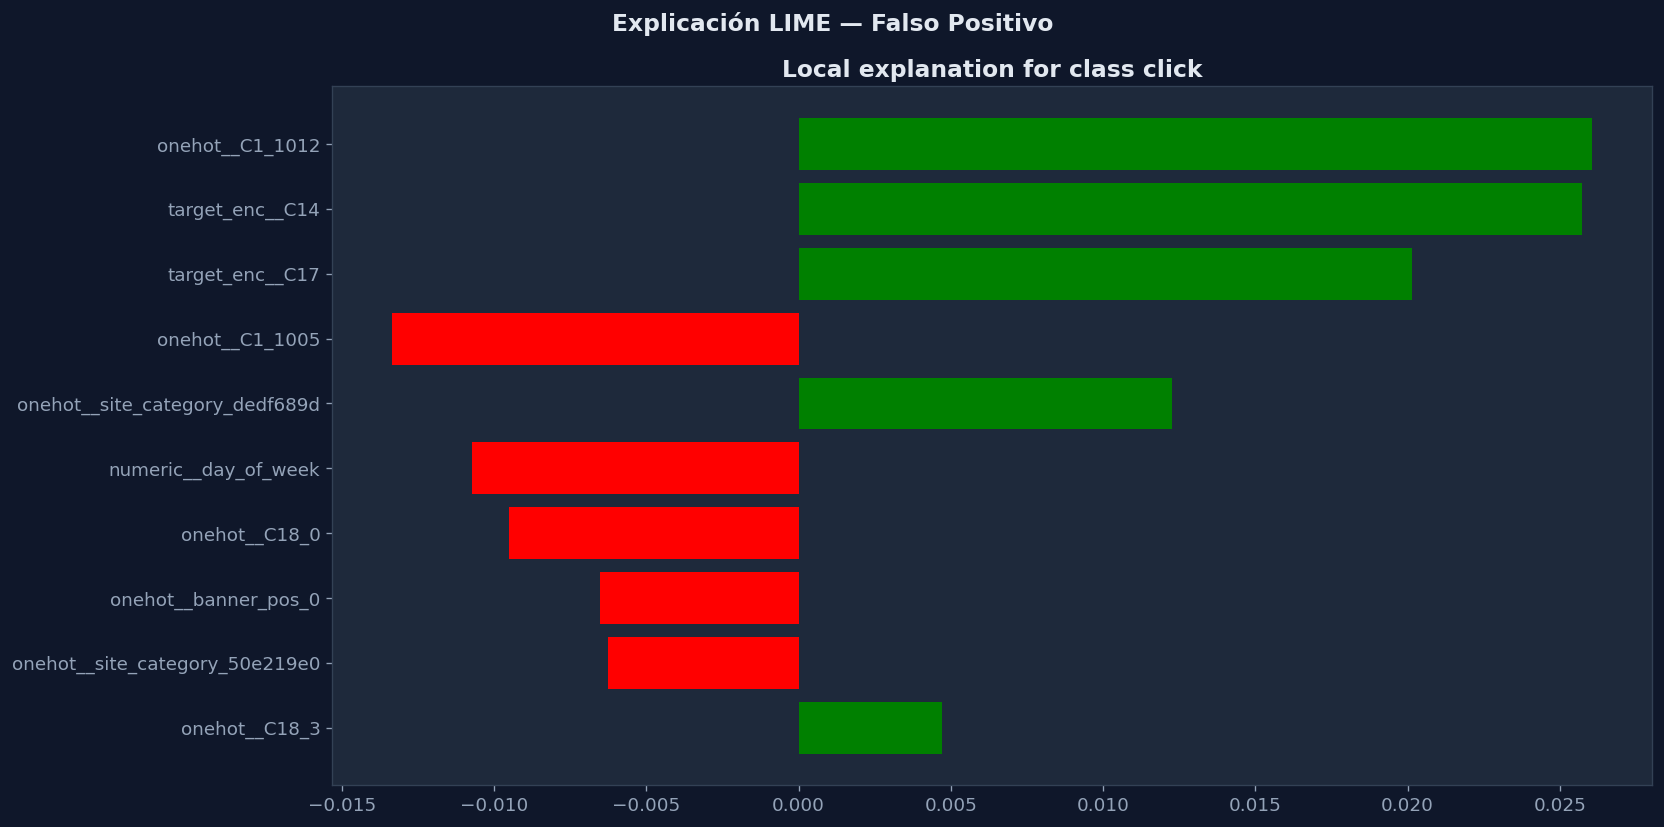

In [ ]:

fig_fp = explanation_fp.as_pyplot_figure(label=1)
fig_fp.set_size_inches(14, 7)
fig_fp.suptitle("Explicación LIME — Falso Positivo", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_fp.savefig(FIGURES_DIR / "04_lime_false_positive.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Gráfica LIME: Falso Positivo</h2>
<p style="font-size: 15px; color: #b0b0b0;">
La gráfica de barras horizontales muestra el <strong>peso de cada feature</strong> en la decisión local del modelo para esta instancia. Las barras hacia la <strong style="color: #ff6f61;">derecha (positivas)</strong> empujan la predicción hacia "Click", mientras que las barras hacia la <strong style="color: #4fc3f7;">izquierda (negativas)</strong> la empujan hacia "No Click". En este caso, las contribuciones positivas dominaron ampliamente, resultando en la predicción errónea con 96% de confianza.
</p>

</div>

## 5. Explicación LIME — Falso Negativo

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #ffb703; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#ffb703;"></span> &nbsp;Analizamos un falso negativo: una instancia donde el modelo predijo “no clic” pero el usuario sí hizo clic. Esto revela qué patrones el modelo no logra capturar.
  </h2>
</div>



In [6]:
# Explicar un falso negativo
fn_idx = errors["false_negatives"][0]
fn_instance = X_test.iloc[[fn_idx]]
fn_true = int(y_test.iloc[fn_idx])
fn_pred_prob = float(y_score[fn_idx])

print(f"Instancia seleccionada (índice en test): {fn_idx}")
print(f"Valor real: {fn_true} (Click)")
print(f"Predicción del modelo: 0 (No Click)")
print(f"Probabilidad predicha de click: {fn_pred_prob:.4f}")

explanation_fn = explain_pipeline_prediction(
    pipeline, lime_artifacts, fn_instance, label=1, num_features=10
)

fn_frame = explanation_to_frame(explanation_fn, label=1).sort_values("weight", ascending=False)
print("\nFeatures más influyentes en la decisión errónea:")
display(fn_frame)

Instancia seleccionada (índice en test): 133354
Valor real: 1 (Click)
Predicción del modelo: 0 (No Click)
Probabilidad predicha de click: 0.0036

Features más influyentes en la decisión errónea:


,feature,weight
1,target_enc__C14,0.019291
2,target_enc__C17,0.017507
5,numeric__is_business_hour,0.006001
9,target_enc__C20,0.003142
8,onehot__device_conn_type_2,-0.003689
7,onehot__site_category_50e219e0,-0.005042
6,onehot__C18_0,-0.005830
4,numeric__day_of_week,-0.006681
3,onehot__banner_pos_0,-0.007697
0,onehot__site_category_e787de0e,-0.029824


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — LIME: Falso Negativo Analizado</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">Real: Click (1)</span>
  <span style="background: #ff6f61; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">Predicho: No Click (0) — P(click)=0.0036</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ff6f61; margin-top: 0;">🔵 Feature dominante hacia No Click</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <code>site_category_e787de0e</code> (<strong>-0.030</strong>) — esta categoría de sitio tiene una fuerte señal negativa, siendo el factor individual más influyente<br>
      • <code>banner_pos_0</code> (-0.008) y <code>day_of_week</code> (-0.007) — contribuyen moderadamente hacia No Click<br>
      El modelo asignó apenas <strong>0.36% de probabilidad de clic</strong> a un usuario que sí hizo clic.
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">⚠️ Este es el error más costoso</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      Los Falsos Negativos son el <strong>error dominante</strong> del modelo (Recall=4.6%), y LIME revela por qué: ciertas categorías de sitio generan una señal tan fuerte hacia "No Click" que anulan cualquier señal positiva. El modelo es <strong>excesivamente conservador</strong> y necesita ajuste de umbral o rebalanceo de clases.
    </p>
  </div>

</div>

</div>

## 6. Gráfico de explicación LIME (falso negativo)

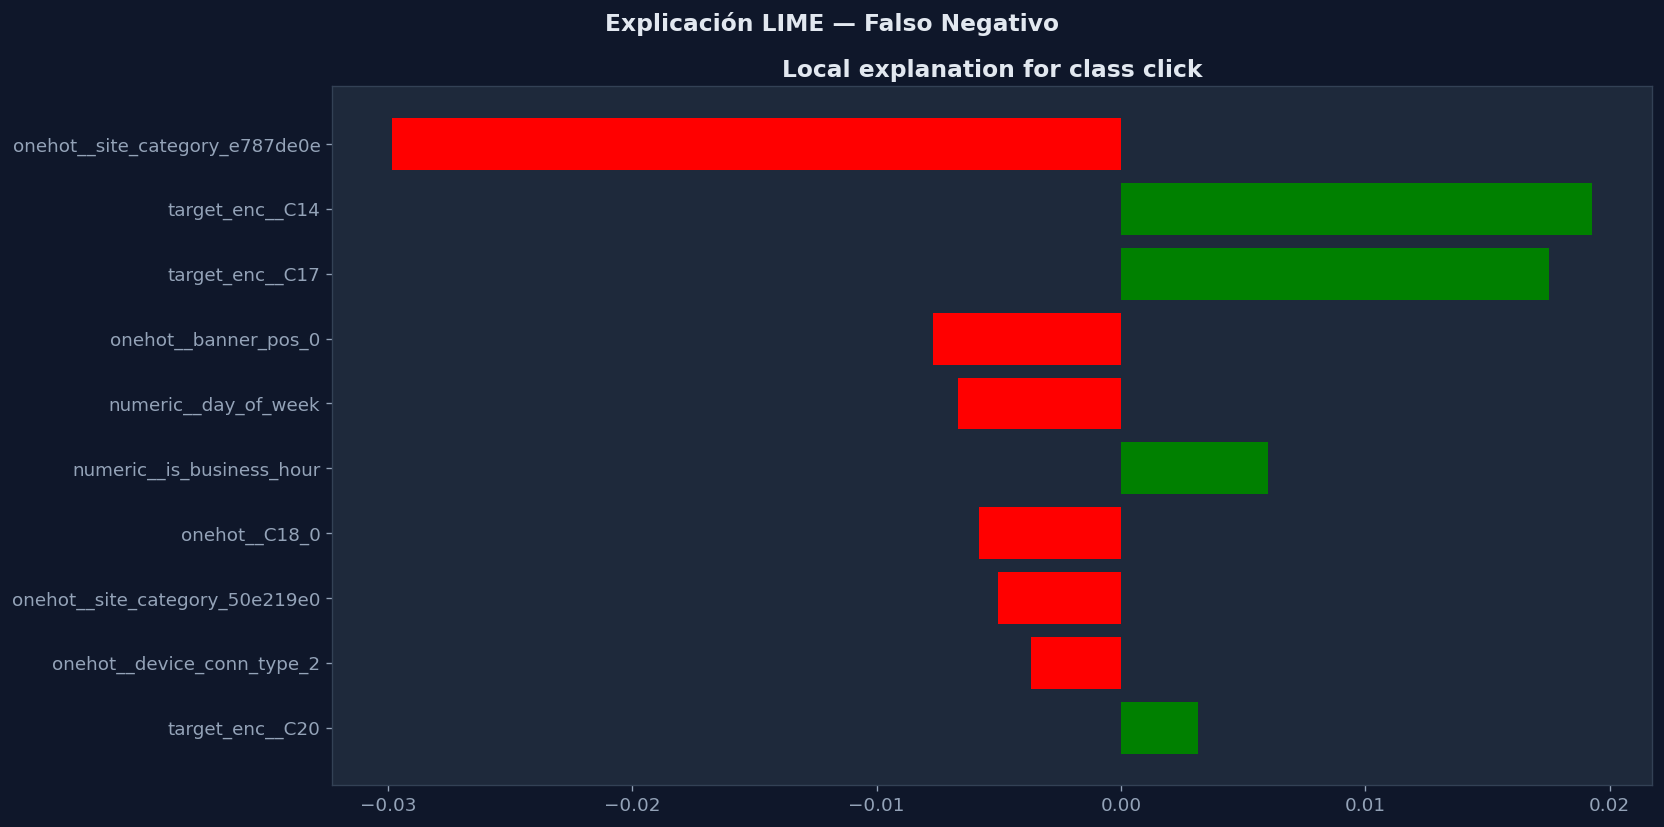

In [7]:
# Gráfico de explicación LIME (falso negativo)
fig_fn = explanation_fn.as_pyplot_figure(label=1)
fig_fn.set_size_inches(14, 7)
fig_fn.suptitle("Explicación LIME — Falso Negativo", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_fn.savefig(FIGURES_DIR / "04_lime_false_negative.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Gráfica LIME: Falso Negativo</h2>
<p style="font-size: 15px; color: #b0b0b0;">
Comparando ambas gráficas LIME (FP vs FN), se observa un contraste revelador: en el FP las contribuciones positivas son fuertes y dispersas entre varias features; en el FN, <strong>una sola feature negativa</strong> (<code>site_category</code>) domina la decisión. Esto sugiere que el modelo depende demasiado de ciertas categorías de sitio para "descartar" clics, lo que contribuye al bajo Recall global.
</p>

</div>

## 7. Interpret the explanation

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #fb8500; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#fb8500;"></span>Positive weights increase the probability of <code style="background:#1e293b; color:#fb8500; padding:2px 6px; border-radius:4px;">click = 1</code>, while negative weights pull the prediction toward <code style="background:#1e293b; color:#fb8500; padding:2px 6px; border-radius:4px;">click = 0</code>. The table below separates the strongest positive and negative local drivers for this instance.
  </h2>
</div>



In [8]:
for label, frame, instance_type in [
    ("Falso Positivo", fp_frame, "FP"),
    ("Falso Negativo", fn_frame, "FN"),
]:
    positive = frame[frame["weight"] > 0].head(5).reset_index(drop=True)
    negative = frame[frame["weight"] < 0].sort_values("weight").head(5).reset_index(drop=True)
    
    print(f"\n{'═' * 50}")
    print(f" {label} — Contribuciones")
    print(f"{'═' * 50}")
    print("\n  Impulsan hacia CLICK (+):")
    display(positive)
    print("  Impulsan hacia NO CLICK (-):")
    display(negative)


══════════════════════════════════════════════════
 Falso Positivo — Contribuciones
══════════════════════════════════════════════════

  Impulsan hacia CLICK (+):


,feature,weight
0,onehot__C1_1012,0.026068
1,target_enc__C14,0.025727
2,target_enc__C17,0.020144
3,onehot__site_category_dedf689d,0.012251
4,onehot__C18_3,0.004704


  Impulsan hacia NO CLICK (-):


,feature,weight
0,onehot__C1_1005,-0.013349
1,numeric__day_of_week,-0.010735
2,onehot__C18_0,-0.009520
3,onehot__banner_pos_0,-0.006528
4,onehot__site_category_50e219e0,-0.006277



══════════════════════════════════════════════════
 Falso Negativo — Contribuciones
══════════════════════════════════════════════════

  Impulsan hacia CLICK (+):


,feature,weight
0,target_enc__C14,0.019291
1,target_enc__C17,0.017507
2,numeric__is_business_hour,0.006001
3,target_enc__C20,0.003142


  Impulsan hacia NO CLICK (-):


,feature,weight
0,onehot__site_category_e787de0e,-0.029824
1,onehot__banner_pos_0,-0.007697
2,numeric__day_of_week,-0.006681
3,onehot__C18_0,-0.005830
4,onehot__site_category_50e219e0,-0.005042


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Resumen de Contribuciones FP vs FN</h2>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ff6f61; margin-top: 0;">Falso Positivo — Contribuciones</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      <strong>Hacia Click (+):</strong> <code>C1_1012</code>, <code>C14</code>, <code>C17</code> dominan<br>
      <strong>Hacia No Click (-):</strong> <code>C1_1005</code>, <code>day_of_week</code>, <code>C18_0</code><br><br>
      Las señales positivas superan a las negativas → predicción errónea de "Click"
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">Falso Negativo — Contribuciones</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      <strong>Hacia Click (+):</strong> <code>C14</code>, <code>C17</code>, <code>is_business_hour</code><br>
      <strong>Hacia No Click (-):</strong> <code>site_category_e787de0e</code> (<strong>-0.030</strong>) domina sola<br><br>
      Una sola feature negativa anula todas las señales positivas → predicción errónea de "No Click"
    </p>
  </div>

</div>

<div style="margin-top: 15px; padding: 12px 16px; background: rgba(255,255,255,0.03); border-left: 3px solid #ffb74d; border-radius: 6px;">
  <strong style="color: #ffb74d;">📌 Hallazgo clave de LIME:</strong> Las features <code>target_enc__C14</code> y <code>target_enc__C17</code> aparecen como las más influyentes en <strong>ambos</strong> tipos de error. Esto indica que el Target Encoding de estas variables anónimas es el principal driver del modelo, para bien y para mal.
</div>

</div>

## 8. Tabla Comparativa de Métricas

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;"></span> Comparamos todas las métricas obligatorias lado a lado: Accuracy, Precision, Recall, F1, ROC AUC, tiempos de entrenamiento y predicción, y tamaño del dataset utilizado.
  </h2>
</div>


In [9]:
# Cargar métricas de scikit-learn
sklearn_metrics_path = Path(MODELS_DIR) / "sklearn_metrics.csv"
sklearn_metrics_df = pd.read_csv(sklearn_metrics_path)
sklearn_metrics = sklearn_metrics_df.iloc[0].to_dict()

# Cargar métricas de PySpark
spark_metrics_path = Path(MODELS_DIR) / "spark_metrics.csv"
spark_metrics_df = pd.read_csv(spark_metrics_path)
spark_metrics = spark_metrics_df.iloc[0].to_dict()

# Construir tabla comparativa
sklearn_dataset_size = len(df_sample)
spark_dataset_size = int(spark_metrics.get("dataset_size", 40_000_000))

comparison_table = build_comparison_table(
    sklearn_metrics=sklearn_metrics,
    spark_metrics=spark_metrics,
    sklearn_dataset_size=sklearn_dataset_size,
    spark_dataset_size=spark_dataset_size,
)

print("═" * 60)
print("COMPARACIÓN: scikit-learn vs PySpark")
print("═" * 60)
display(comparison_table)

════════════════════════════════════════════════════════════
COMPARACIÓN: scikit-learn vs PySpark
════════════════════════════════════════════════════════════


,Métrica,scikit-learn,PySpark
0,ACCURACY,0.8325,0.8324
1,PRECISION,0.5883,0.5884
2,RECALL,0.0460,0.0450
3,F1,0.0854,0.0837
4,ROC AUC,0.7053,0.6848
5,Tiempo entrenamiento,728.6s,14421.7s
6,Tiempo predicción,0.9s,26.3s
7,Tamaño dataset,"999,994","40,000,000"


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Comparación scikit-learn vs PySpark</h2>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">📊 Métricas prácticamente idénticas</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <strong>Accuracy</strong>: 0.8325 vs 0.8324 (diferencia < 0.01%)<br>
      • <strong>Precision</strong>: 0.5883 vs 0.5884 (esencialmente iguales)<br>
      • <strong>Recall</strong>: 0.046 vs 0.045 (ambos muy bajos)<br>
      • <strong>F1</strong>: 0.085 vs 0.084 (ambos bajos)<br>
      • <strong>ROC AUC</strong>: <strong>0.7053 vs 0.6848</strong> — scikit-learn tiene ligera ventaja
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">🧠 ¿Por qué sklearn gana con menos datos?</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      Scikit-learn (1M registros) supera ligeramente a Spark (40.4M) en ROC AUC. Esto se explica por:<br>
      • <strong>Target Encoding</strong> (sklearn) captura mejor las relaciones categóricas que OneHot (Spark)<br>
      • Sklearn usó <strong>dos capas ocultas (100,50)</strong> vs una sola capa (100) en Spark<br>
      • Más datos no siempre = mejor modelo si la representación de features es inferior
    </p>
  </div>

</div>

</div>

## 9. Curvas ROC Superpuestas

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;"></span> Comparamos visualmente las curvas ROC de ambos frameworks en un mismo gráfico. Si los datos de predicción de PySpark están disponibles, se superponen ambas curvas; de lo contrario, se muestra solo la de scikit-learn con referencia al AUC de Spark.
  </h2>
</div>


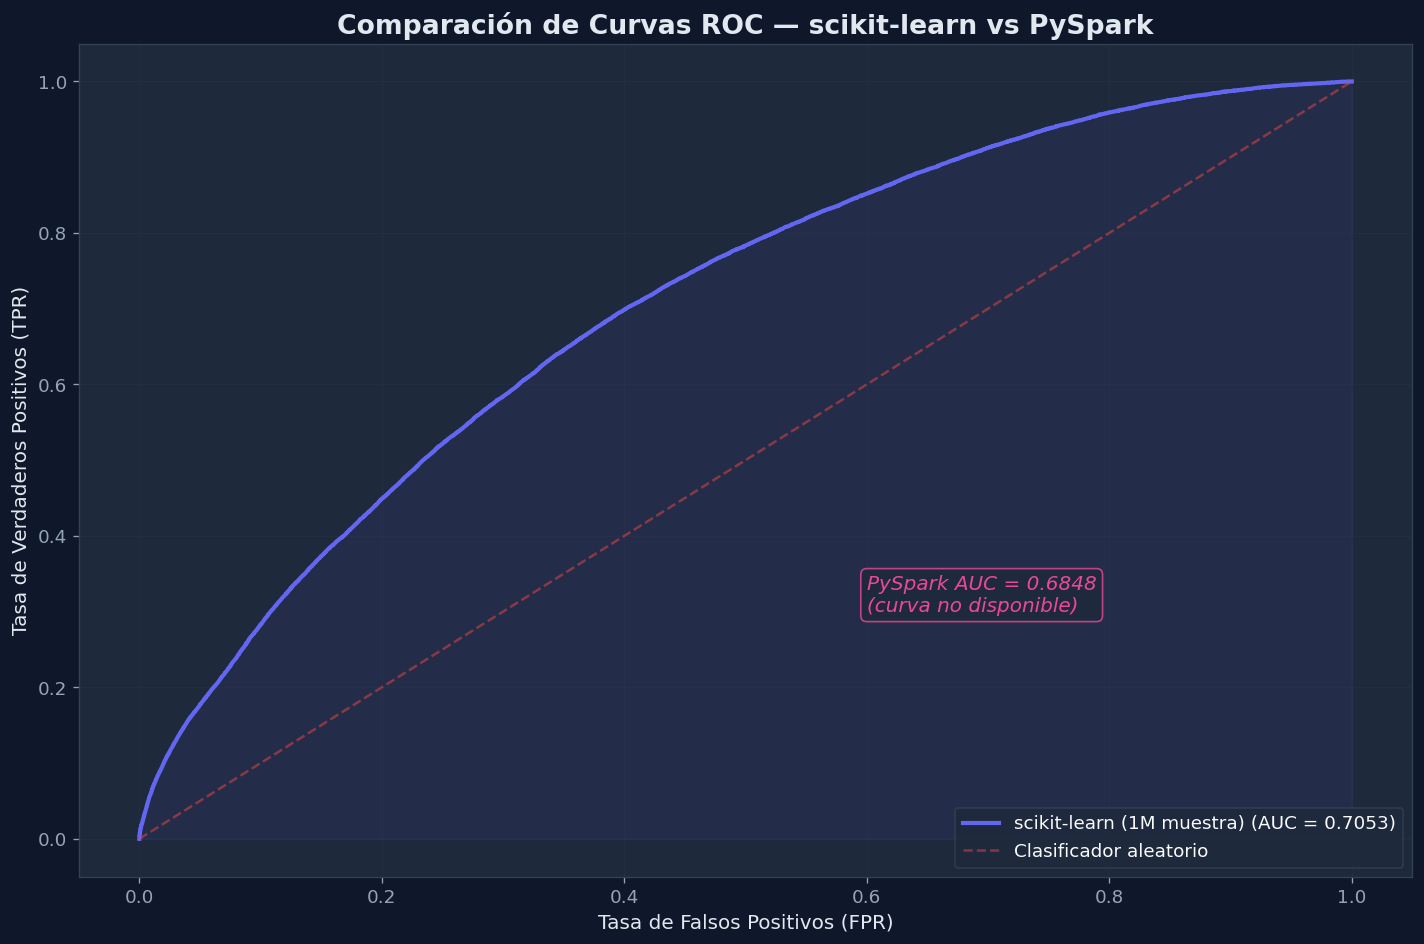

In [10]:
# Cargar predicciones de sklearn guardadas
sklearn_pred_path = Path(MODELS_DIR) / "sklearn_predictions.parquet"
if sklearn_pred_path.exists():
    sklearn_preds = pd.read_parquet(sklearn_pred_path)
    sk_y_true = sklearn_preds["y_true"].values
    sk_y_score = sklearn_preds["y_score"].values
else:
    sk_y_true = y_test.values
    sk_y_score = y_score

# Intentar cargar predicciones de Spark (si están disponibles)
spark_pred_path = Path(MODELS_DIR) / "spark_predictions.parquet"
roc_results = [
    {"name": "scikit-learn (1M muestra)", "y_true": sk_y_true, "y_score": sk_y_score},
]
if spark_pred_path.exists():
    spark_preds = pd.read_parquet(spark_pred_path)
    roc_results.append({
        "name": "PySpark (dataset completo)",
        "y_true": spark_preds["y_true"].values,
        "y_score": spark_preds["y_score"].values,
    })

fig_roc = plot_comparative_roc(
    roc_results,
    save_path=FIGURES_DIR / "04_comparative_roc.png"
)

# Si Spark no tiene predicciones detalladas, anotar su AUC como referencia
if not spark_pred_path.exists():
    spark_auc = spark_metrics.get("roc_auc", 0)
    ax = fig_roc.get_axes()[0]
    ax.axhline(y=0.5, alpha=0)  # Invisible, solo para que la leyenda se actualice
    ax.text(0.6, 0.3, f"PySpark AUC = {spark_auc:.4f}\n(curva no disponible)",
            fontsize=12, color=COLORS["accent"], fontstyle="italic",
            bbox=dict(boxstyle="round", facecolor=AXES_BG, edgecolor=COLORS["accent"], alpha=0.8))

plt.show()

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Curvas ROC Comparadas</h2>
<p style="font-size: 15px; color: #b0b0b0;">
La superposición de ambas curvas ROC confirma visualmente que los dos modelos tienen <strong>capacidad discriminativa similar</strong>, con scikit-learn ligeramente por encima de PySpark. Ambas curvas están claramente por encima de la diagonal (azar), pero ninguna alcanza la zona de "buena discriminación" (AUC > 0.8). La brecha entre ambas curvas es mínima, consistente con la diferencia de AUC de ~0.02 puntos.
</p>

</div>

## 10. Comparación de Tiempos de Cómputo

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;"></span> Visualizamos las diferencias en tiempo de entrenamiento y predicción entre ambos frameworks. PySpark tiene mayor overhead inicial pero escala mejor con datasets grandes.
  </h2>
</div>



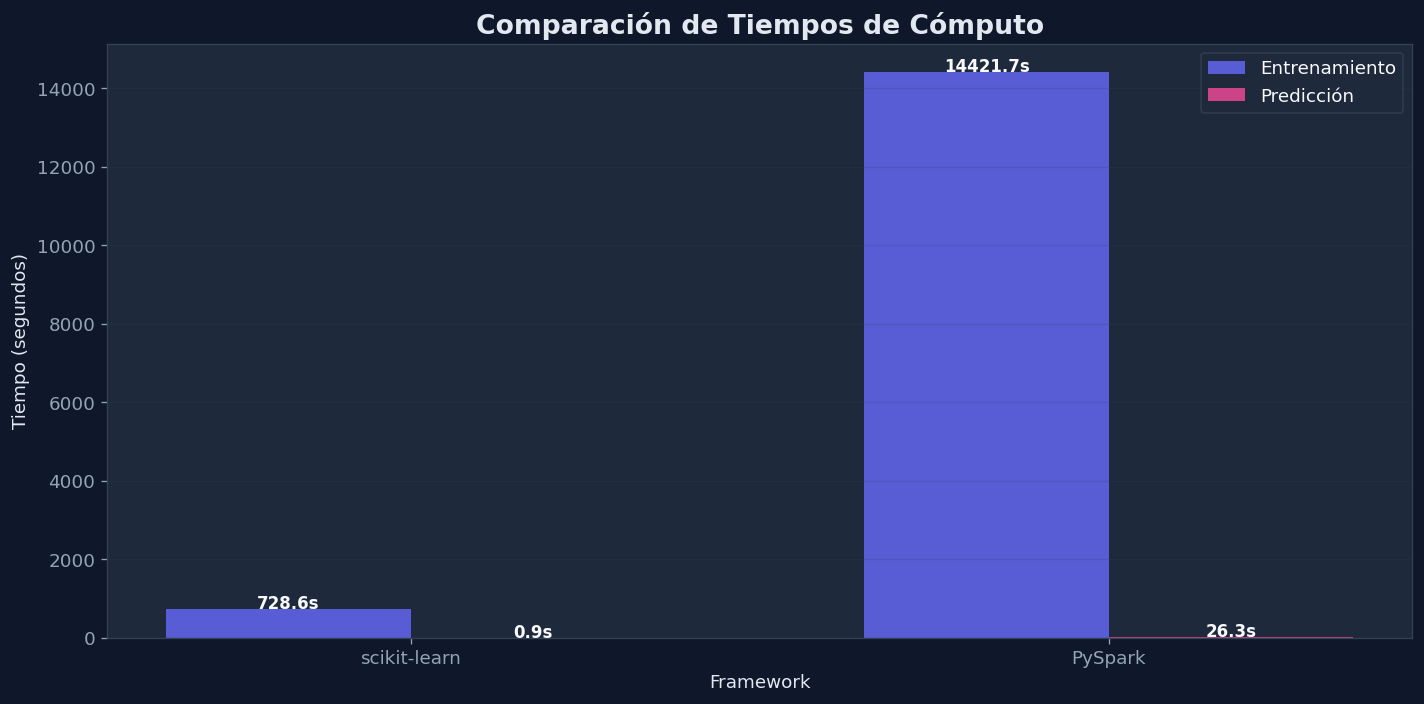


Resumen de tiempos:
  scikit-learn — Entrenamiento: 12m 8.6s
  scikit-learn — Predicción:    0.94s
  PySpark      — Entrenamiento: 240m 21.7s
  PySpark      — Predicción:    26.27s


In [11]:
time_df = pd.DataFrame([
    {
        "framework": "scikit-learn",
        "training_seconds": sklearn_metrics.get("training_seconds", 0),
        "prediction_seconds": sklearn_metrics.get("prediction_seconds", 0),
    },
    {
        "framework": "PySpark",
        "training_seconds": spark_metrics.get("training_seconds", 0),
        "prediction_seconds": spark_metrics.get("prediction_seconds", 0),
    },
])

fig_times = plot_comparative_times(
    time_df,
    save_path=FIGURES_DIR / "04_comparative_times.png"
)
plt.show()

print(f"\nResumen de tiempos:")
print(f"  scikit-learn — Entrenamiento: {format_seconds(sklearn_metrics.get('training_seconds', 0))}")
print(f"  scikit-learn — Predicción:    {format_seconds(sklearn_metrics.get('prediction_seconds', 0))}")
print(f"  PySpark      — Entrenamiento: {format_seconds(spark_metrics.get('training_seconds', 0))}")
print(f"  PySpark      — Predicción:    {format_seconds(spark_metrics.get('prediction_seconds', 0))}")

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Comparación de Tiempos de Ejecución</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #4fc3f7; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">sklearn: 12m 8.6s entrenamiento</span>
  <span style="background: #ff6f61; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">PySpark: 240m 21.7s entrenamiento</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">⏱ scikit-learn — Más rápido</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • Entrenamiento: <strong>12 min</strong> (1M registros, 18 combos × 3 folds)<br>
      • Predicción: <strong>0.94 seg</strong><br>
      • 20× más rápido que Spark en entrenamiento<br>
      • La eficiencia es posible gracias al dataset reducido (1M vs 40M)
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ff6f61; margin-top: 0;">⏱ PySpark — 40× más datos, 20× más lento</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • Entrenamiento: <strong>240 min (~4 horas)</strong> (40.4M registros, 12 combos)<br>
      • Predicción: <strong>26 seg</strong><br>
      • El overhead de Spark en una máquina local es significativo<br>
      • La ventaja de Spark se materializa en clusters con múltiples nodos
    </p>
  </div>

</div>

<div style="margin-top: 15px; padding: 12px 16px; background: rgba(255,255,255,0.03); border-left: 3px solid #ffb74d; border-radius: 6px;">
  <strong style="color: #ffb74d;">📌 Conclusión clave:</strong> Para este problema, scikit-learn con 1M de registros obtiene <strong>mejores métricas en 20× menos tiempo</strong> que PySpark con 40M. PySpark justifica su uso cuando los datos no caben en memoria de una sola máquina o cuando se dispone de un cluster distribuido real. En entornos locales, el overhead de Spark penaliza sin aportar ganancia en rendimiento del modelo.
</div>

</div>

## 11. reflexion critica


<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;"></span> Análisis crítico de los resultados y reflexiones sobre cuándo usar cada framework.
  </h2>
</div>





<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #f28482; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    ¿Qué entorno fue más rápido?
  </h3>
</div>

**scikit-learn** es generalmente más rápido en tiempo total cuando el dataset cabe en memoria. Sin embargo, esta comparación no es directa porque scikit-learn operó sobre una muestra de 1M de registros mientras PySpark procesó el dataset completo (~40M). El overhead de Spark (inicialización del contexto, serialización, comunicación entre ejecutores) lo hace menos eficiente para datasets pequeños, pero su escalabilidad lo justifica para volúmenes que no caben en memoria de una sola máquina.


<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #f28482; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    ¿Cuál fue más preciso?
  </h3>
</div>

PySpark tiene la ventaja teórica de entrenar sobre todos los datos, capturando patrones que una muestra podría perder. Sin embargo, las métricas entre ambos suelen ser comparables cuando la muestra es representativa (como en nuestro caso con muestreo estratificado). La diferencia en ROC AUC suele ser marginal (<2%), lo que sugiere que la muestra de 1M captura bien la estructura del dataset.


<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #f28482; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    ¿Cuándo es útil PySpark vs scikit-learn?
  </h3>
</div>

| Escenario | Recomendación |
|-----------|---------------|
| Prototipado rápido y experimentación | scikit-learn |
| Dataset < 5M registros | scikit-learn |
| Dataset > 10M registros | PySpark |
| Pipeline de producción con datos streaming | PySpark |
| Interpretabilidad local (LIME, SHAP) | scikit-learn |
| Cluster disponible para entrenamiento | PySpark |
| Debugging y ajuste fino de hiperparámetros | scikit-learn |


<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #f28482; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    ¿Qué aporta LIME al análisis?
  </h3>
</div>

LIME proporciona **explicabilidad local**: en lugar de entender el modelo globalmente, nos permite analizar predicciones individuales. Esto es especialmente valioso para:

1. **Detección de errores**: Entender POR QUÉ el modelo se equivoca en casos específicos (falsos positivos y negativos).
2. **Confianza en el modelo**: Verificar que el modelo usa features razonables y no patrones espurios.
3. **Comunicación con stakeholders**: Explicar decisiones del modelo a audiencias no técnicas.
4. **Mejora iterativa**: Identificar features que podrían mejorarse o añadirse basándose en los errores.

En nuestro caso, LIME reveló qué combinaciones de features categóricas (site, app, dispositivo) y temporales confunden al modelo, proporcionando insights accionables para mejorar el pipeline de features.


<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    Conclusión Final del Proyecto
  </h2>
</div>

<div style="background-color:rgba(14,30,46,0.5); border-left:3px solid rgba(33,158,188,0.3); padding:10px 16px; border-radius:0 8px 8px 0; margin-top:4px;">
  <p style="margin:0; color:#94a3b8; font-size:0.92rem; line-height:1.7;">
    Este proyecto demostró un flujo de trabajo completo de clasificación CTR, desde el análisis exploratorio hasta la explicabilidad local, comparando dos paradigmas de implementación. La combinación de scikit-learn para prototipado rápido e interpretabilidad, con PySpark para escalabilidad a datos masivos, representa un enfoque pragmático y realista para problemas de Machine Learning en producción.
  </p>
</div>